In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import MIRS, mep_opt, gb_opt, visualize 
from scipy.optimize import Bounds, LinearConstraint, minimize 
import utils 
from matplotlib.cm import get_cmap 
import time 
import math 
import visualize 
import problem_generator 
import time 
import os 
import pickle 
from datetime import datetime 

In [3]:
n_scenarios = 1
seed = np.random.choice(range(1,1000))
n_wps = np.sort(np.random.choice(range(10,40), (n_scenarios,), False))
n_ags = np.sort(np.random.choice(range(5,15), (n_scenarios,)))
print(f"seed:{seed}\nn_wps:{n_wps}\nn_ags:{n_ags}")

seed:509
n_wps:[24]
n_ags:[5]


In [4]:
t_arr_mep = []
t_arr_gb = []
t_arr_slsqp = []
c_arr_mep = []
c_arr_gb = []
c_arr_slsqp = []
scn_arr = []

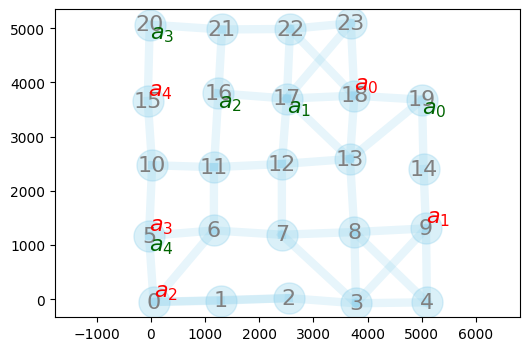

w:0.001	h:0.036

beta: 1.0000e-06	cost: 746468.403	tolb: 4.688e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(240,)
w:0.002	h:0.071

beta: 2.9764e-06	cost: 272853.074	tolb: 3.649e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(240,)
w:0.010	h:0.140

beta: 8.8587e-06	cost: 111227.044	tolb: 4.034e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(232,)
w:0.038	h:0.270

beta: 2.6367e-05	cost: 51294.691	tolb: 1.656e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(192,)
w:0.154	h:0.502

beta: 7.8476e-05	cost: 23641.826	tolb: 3.188e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(100,)
w:0.614	h:0.883

beta: 2.3357e-04	cost: 9636.730	tolb: 3.885e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(34,)
w:2.448	h:1.422

beta: 6.9519e-04	cost: 3519.298	tolb: 2.552e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(14,)
w:9.672	h:2.045

beta: 2.0691e-03	cost: 1229.983	tolb: 1.978e-06	n_active_waypoints:24	tol_mag:3.64	Hbshape:(9,)
w:36.903	h:2.620

beta: 6.1585e-03	cost: 436.869	tolb: 2.394e-08	n_active_wa

In [6]:
for l in range(n_scenarios):

    n_waypoints = n_wps[l]
    n_agents = n_ags[l]
    net_params, tolArray = problem_generator.get_network_params(n_waypoints, tol_range=[3.0, 5.0], name="grid")
    cbf_mode = utils.get_cbf_mode("rect", tolArray) # options: "el", "lin", "rect"

    # cost mode options
    cost_mode = 'sum' # 'slowest'
    lm = 1 # for slowest
    

    # create a mirs environment
    mirs = MIRS.MIRS(
        n_waypoints, 
        n_agents, 
        tolArray, 
        net_params,
        seed=seed, 
        offset_energy=1,
        stagewiseCostCoeffs=np.array([0.1, 10.0, 0.1]),
        selfHop=0,
        cost_mode=cost_mode,
        lm = lm,
        ca_cbf=cbf_mode,
        filter_wp_thresh=1e-10,
        prune_mode=False,
        printFlag=False)
    
    # mirs visualization 
    cmap = plt.get_cmap('tab20') 
    agent_colors = {a: cmap(i / mirs.n_agents) for i, a in enumerate(range(mirs.n_agents))} 
    visualize.plotNetwork(
        figuresize=(6,4), 
        wp_xy=mirs.wp_locations, 
        mask=mirs.mask, 
        dist_mat=mirs.dist_mat, 
        sd_mat=mirs.sd_mat, 
        routes=[], 
        schedules=[],
        agent_colors=agent_colors, 
        showEdgeLength=False) 

    # initial condition and general config
    T0 = mirs.sched_mat.copy()
    V0 = mirs.speed_vec.copy()
    active_waypoints = range(mirs.n_waypoints) 
    mirs.prune_mode = True 
    mirs.filter_wp_thresh = 0.01

    # ================== # 
    # MEP OPTIMIZER
    # ================== # 
    
    t0_mep = time.time()

    optim_config1, anneal_config1 = utils.set_mep_opt_config("cbf")
    mep_optimizer1 = mep_opt.MIRSOptimizer(mirs, optim_config1, anneal_config1)

    T_array1, V_array1, F1, Pb_a1, chi_array1, t_compute_array1 = mep_optimizer1.anneal(  
        T0, 
        V0, 
        active_waypoints=active_waypoints, 
        annealPrint=True) 
    t1_mep = time.time() 
    rt_mep = t1_mep - t0_mep

    agent_routes1, agent_schedules1 = mep_optimizer1.mirs.solution_table(
        Pb_a1, 
        T_array1[-1],
        V_array1[-1],
        mep_optimizer1.b_arr[-1]
    )

    reach_mat1, association_mat1 = mep_optimizer1.mirs.calc_agent_reach_mat_v1(
        T_array1[-1],
        V_array1[-2],
        beta=mep_optimizer1.b_arr[-1]
    )

    solution_data1 = {
        'name':'MEP_CBF',
        'n_agents':mirs.n_agents,
        'wp_xy':mirs.wp_locations,
        'wp_params':net_params,
        'mask':mirs.mask,
        'dist_mat':mirs.dist_mat,
        'sd_mat':mirs.sd_mat,
        'T_array':T_array1,
        'V_array':V_array1,
        'cost':F1,
        'runtime':rt_mep,
        'final_Pb':Pb_a1,
        'chi_arr':chi_array1,
        'agent_routes':agent_routes1,
        'agent_schedules':agent_schedules1,
        'association_mat':association_mat1,
        'agent_colors':agent_colors,
        'b_arr':mep_optimizer1.b_arr,
        'processing_time':mirs.process_T,
        'cat':mirs.tolArray,
        'optim_config':optim_config1,
        'anneal_config':anneal_config1,
        'cost_mode':cost_mode,
        'cbf_mode':cbf_mode,
        'seed':seed,
        'offset_energy':mirs.offset_energy,
        'stagewise_cost_coeffs':mirs.stagewiseCostCoeffs,
        'prune_mode':mirs.prune_mode,
        'filter_wp_thresh':mirs.filter_wp_thresh,
        'inf':mirs.INF,
        'speed_lim_mat':mirs.speed_lim_mat,
        'start_times':mirs.start_times,
        't_up':mirs.T_upper_bound,
        'agent_weights':mirs.agent_weights,
        'wp_weights':mirs.wp_weights,
        'lm':mirs.lm,
        'self_hop':mirs.selfHop
    }

    # # ================== # 
    # # SLSQP OPTIMIZER 
    # # ================== # 

    # t0_slsqp = time.time()

    # optim_config2, anneal_config2 = utils.set_mep_opt_config("slsqp")
    # mep_optimizer2 = mep_opt.MIRSOptimizer(mirs, optim_config2, anneal_config2)

    # T_array2, V_array2, F2, Pb_a2, chi_array2, t_compute_array2 = mep_optimizer2.anneal(  
    #     T0, 
    #     V0, 
    #     active_waypoints=active_waypoints, 
    #     annealPrint=False) 
    # t1_slsqp = time.time()
    # rt_slsqp = t1_slsqp - t0_slsqp

    # agent_routes2, agent_schedules2 = mep_optimizer2.mirs.solution_table(
    #     Pb_a2, 
    #     T_array2[-1],
    #     V_array2[-1],
    #     mep_optimizer2.b_arr[-1]
    # )

    # reach_mat2, association_mat2 = mep_optimizer2.mirs.calc_agent_reach_mat_v1(
    #     T_array2[-1],
    #     V_array2[-2],
    #     beta=mep_optimizer2.b_arr[-1]
    # )

    # solution_data2 = {
    #     'name':'MEP_SLSQP',
    #     'n_agents':mirs.n_agents,
    #     'wp_xy':mirs.wp_locations,
    #     'wp_params':net_params,
    #     'mask':mirs.mask,
    #     'dist_mat':mirs.dist_mat,
    #     'sd_mat':mirs.sd_mat,
    #     'T_array':T_array2,
    #     'V_array':V_array2,
    #     'cost':F2,
    #     'runtime':rt_slsqp,
    #     'final_Pb':Pb_a2,
    #     'chi_arr':chi_array2,
    #     'agent_routes':agent_routes2,
    #     'agent_schedules':agent_schedules2,
    #     'association_mat':association_mat2,
    #     'agent_colors':agent_colors,
    #     'b_arr':mep_optimizer2.b_arr,
    #     'processing_time':mirs.process_T,
    #     'cat':mirs.tolArray,
    #     'optim_config':optim_config2,
    #     'anneal_config':anneal_config2,
    #     'cost_mode':cost_mode,
    #     'cbf_mode':cbf_mode,
    #     'seed':seed,
    #     'offset_energy':mirs.offset_energy,
    #     'stagewise_cost_coeffs':mirs.stagewiseCostCoeffs,
    #     'prune_mode':mirs.prune_mode,
    #     'filter_wp_thresh':mirs.filter_wp_thresh,
    #     'inf':mirs.INF,
    #     'speed_lim_mat':mirs.speed_lim_mat,
    #     'start_times':mirs.start_times,
    #     't_up':mirs.T_upper_bound,
    #     'agent_weights':mirs.agent_weights,
    #     'wp_weights':mirs.wp_weights,
    #     'lm':mirs.lm,
    #     'self_hop':mirs.selfHop
    # }

    # # ================== # 
    # # GUROBI OPTIMIZER
    # # ================== # 

    # t0_gb = time.time()
    # gb_optimizer = gb_opt.MIRSGurobiOptimizer(mirs, "gb_mirs_model")
    # gb_optimizer.model.setParam("OutputFlag", 0)
    # gb_optimizer.optimize(time_limit=1200, mip_gap=0.05, stagnation_limit=20000)
    # t1_gb = time.time()
    # rt_gb = t1_gb - t0_gb

    # agent_routes3, agent_schedules3, agent_speeds3, T_mat_gb, assoc_mat_gb = gb_optimizer.extract_routes_and_schedules()
    # F3 = gb_optimizer.model.ObjVal

    # solution_data3 = {
    #     'name':'GUROBI',
    #     'n_agents':mirs.n_agents,
    #     'wp_xy':mirs.wp_locations,
    #     'wp_params':net_params,
    #     'mask':mirs.mask,
    #     'dist_mat':mirs.dist_mat,
    #     'sd_mat':mirs.sd_mat,
    #     'T_mat':T_mat_gb,
    #     'speeds':agent_speeds3,
    #     'cost':F3,
    #     'runtime':rt_gb,
    #     'agent_routes':agent_routes3,
    #     'agent_schedules':agent_schedules3,
    #     'association_mat':assoc_mat_gb,
    #     'agent_colors':agent_colors,
    #     'processing_time':mirs.process_T,
    #     'cat':mirs.tolArray,
    #     'cost_mode':cost_mode,
    #     'seed':seed,
    #     'stagewise_cost_coeffs':mirs.stagewiseCostCoeffs,
    #     'inf':mirs.INF,
    #     'speed_lim_mat':mirs.speed_lim_mat,
    #     'start_times':mirs.start_times,
    #     't_up':mirs.T_upper_bound,
    #     'agent_weights':mirs.agent_weights,
    #     'wp_weights':mirs.wp_weights,
    #     'self_hop':mirs.selfHop
    # }

    # # ================== # 
    # # STORE ABOVE DATA
    # # ================== # 
    # folder_path = f"Final_results/compare_scenarios_{n_scenarios}_seed_{seed}"
    # os.makedirs(folder_path, exist_ok=True)

    # # Generate timestamp filename
    # timestamp = datetime.now().strftime("%Y_%m_%d__%H_%M_%S")
    # file_name = f"nwp_{mirs.n_waypoints}_na_{mirs.n_agents}_{timestamp}.pkl"
    # file_path = os.path.join(folder_path, file_name)

    # data = {
    #     "solution_data1":solution_data1,
    #     "solution_data2":solution_data2,
    #     "solution_data3":solution_data3
    # }

    # # Save
    # with open(file_path, "wb") as f:
    #     pickle.dump(data, f)

    # print(f"Saved as {file_name}")

    # # ================== # 
    # # STORE COMPARISON DATA
    # # ================== # 

    # c_arr_mep.append(F1)
    # c_arr_slsqp.append(F2)
    # c_arr_gb.append(F3)
    # t_arr_mep.append(t1_mep - t0_mep)
    # t_arr_slsqp.append(t1_slsqp - t0_slsqp)
    # t_arr_gb.append(t1_gb - t0_gb)
    # scn_arr.append([n_waypoints, n_agents])

    # # ================== # 
    # # PRINT SIMULATION PROGRESS & DATA
    # # ================== # 

    # print(f"n_scene:{l}\n\tcosts:\tmep_cbf:{F1:.2f}\tmep_slsqp:{F2:.2f}\tgrb:{F3:.2f}\n\truntimes:\tmep_cbf:{rt_mep:.2f}\tmep_slsqp:{rt_slsqp:.2f}\tgrb:{rt_gb:.2f}")


In [36]:

comparison_data = {
    'c_arr_mep':c_arr_mep,
    'c_arr_slsqp':c_arr_slsqp,
    'c_arr_gb':c_arr_gb,
    't_arr_mep':t_arr_mep,
    't_arr_slsqp':t_arr_slsqp,
    't_arr_gb':t_arr_gb
}

timestamp = datetime.now().strftime("%Y_%m_%d__%H_%M_%S")
file_name1 = f"cost_runtime_data_{timestamp}.pkl"
file_path1 = os.path.join(folder_path, file_name1)
# Save
with open(file_path1, "wb") as f:
    pickle.dump(comparison_data, f)

print(f"Saved as {file_name}")



Saved as nwp_14_na_6_2026_04_08__16_15_12.pkl


In [3]:
def load_pkl_file(folder_path, prefix, mode="random", index=None):
    """
    mode: "random" or "manual"
    index: used when mode="manual"
    """
    
    # Get all matching .pkl files
    files = [
        f for f in os.listdir(folder_path)
        if f.startswith(prefix) and f.endswith(".pkl")
    ]
    
    if not files:
        raise FileNotFoundError("No matching .pkl files found.")
    
    # Sort for consistency (useful for manual selection)
    files.sort()
    
    # Choose file
    if mode == "random":
        chosen_file = random.choice(files)
    
    elif mode == "manual":
        if index is None or index >= len(files):
            raise ValueError("Provide a valid index for manual selection.")
        
        # Show options
        print("Available files:")
        for i, f in enumerate(files):
            print(f"{i}: {f}")
        
        chosen_file = files[index]
    
    else:
        raise ValueError("mode must be 'random' or 'manual'")
    
    file_path = os.path.join(folder_path, chosen_file)
    
    # Load pickle file
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    
    print(f"Loaded file: {chosen_file}")
    return data

In [7]:
folder_path = "Final_results/compare_scenarios_10_seed_148"
prefix1 = "nwp"
data1 = load_pkl_file(folder_path, prefix1, mode="random", index=0)
solution_data1 = data1["solution_data1"]

prefix2 = "cost_runtime_data"
compare_data = load_pkl_file(folder_path, prefix2, mode="random", index=0)


Loaded file: nwp_14_na_4_2026_04_07__15_26_54.pkl
Loaded file: cost_runtime_data_2026_04_07__18_24_33.pkl


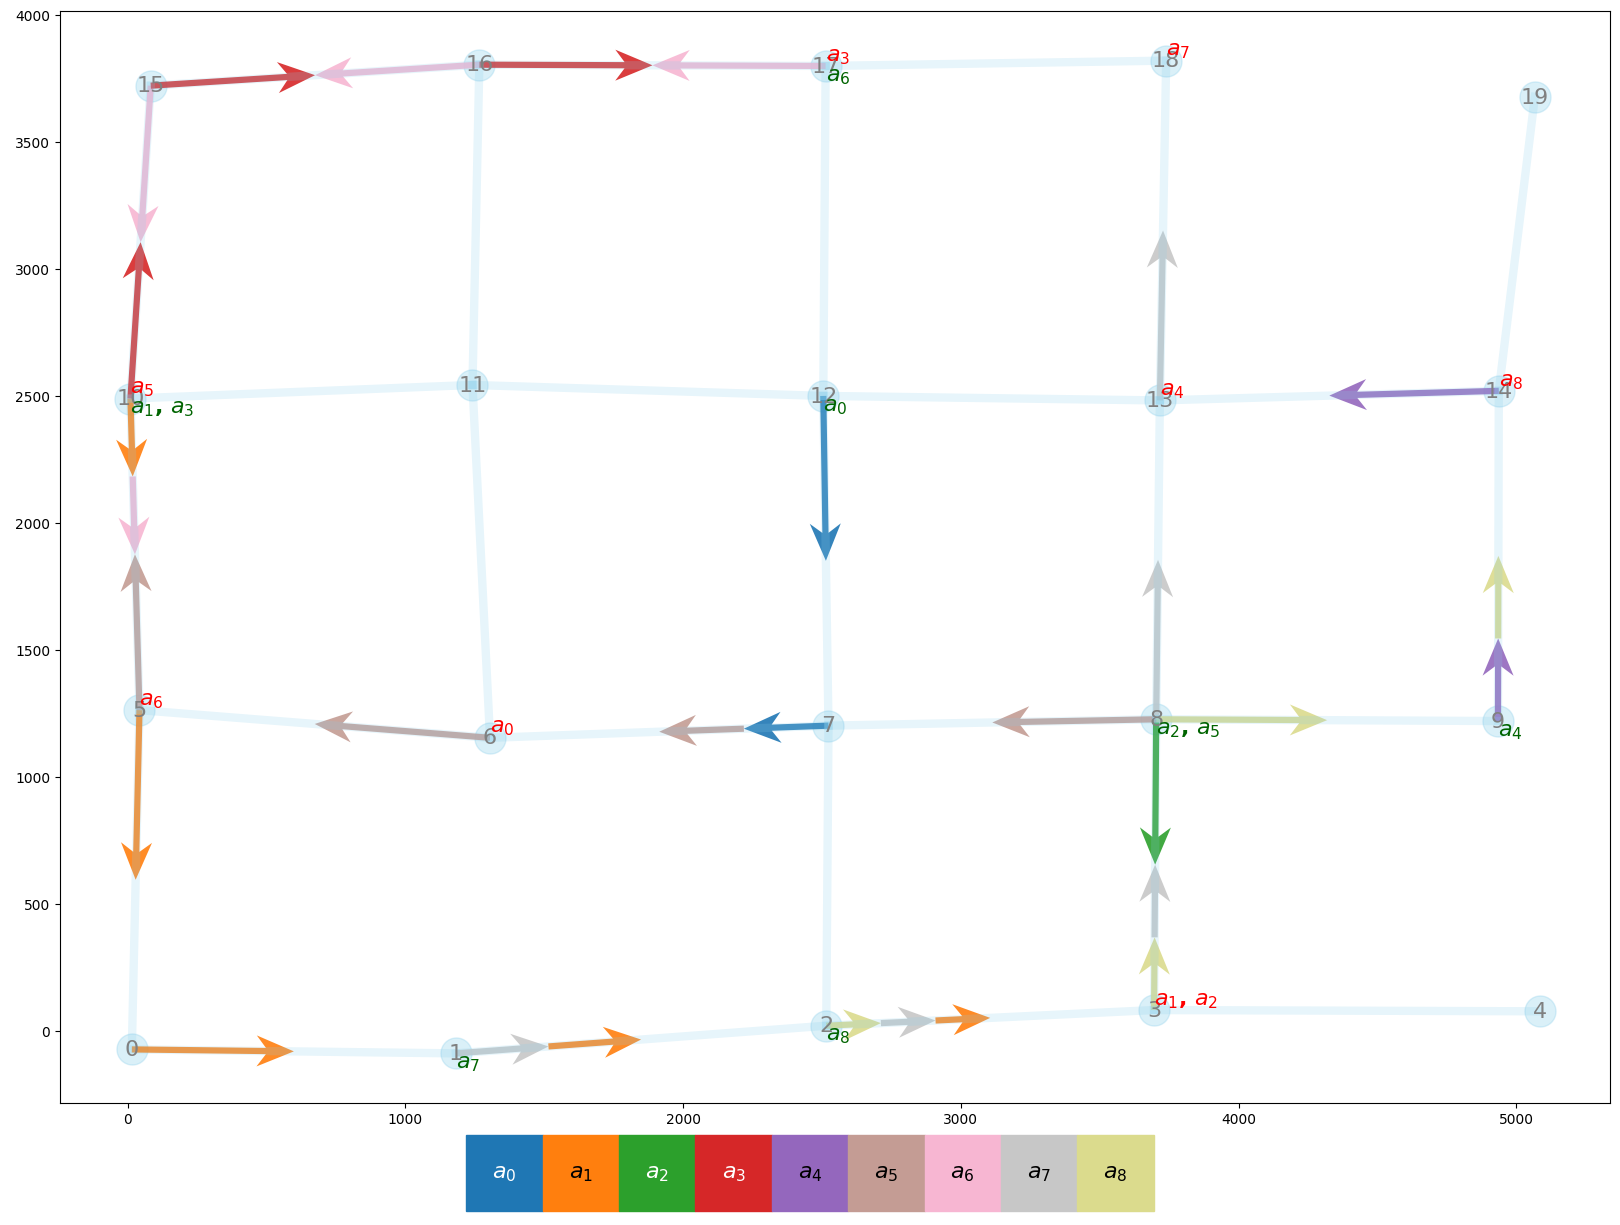

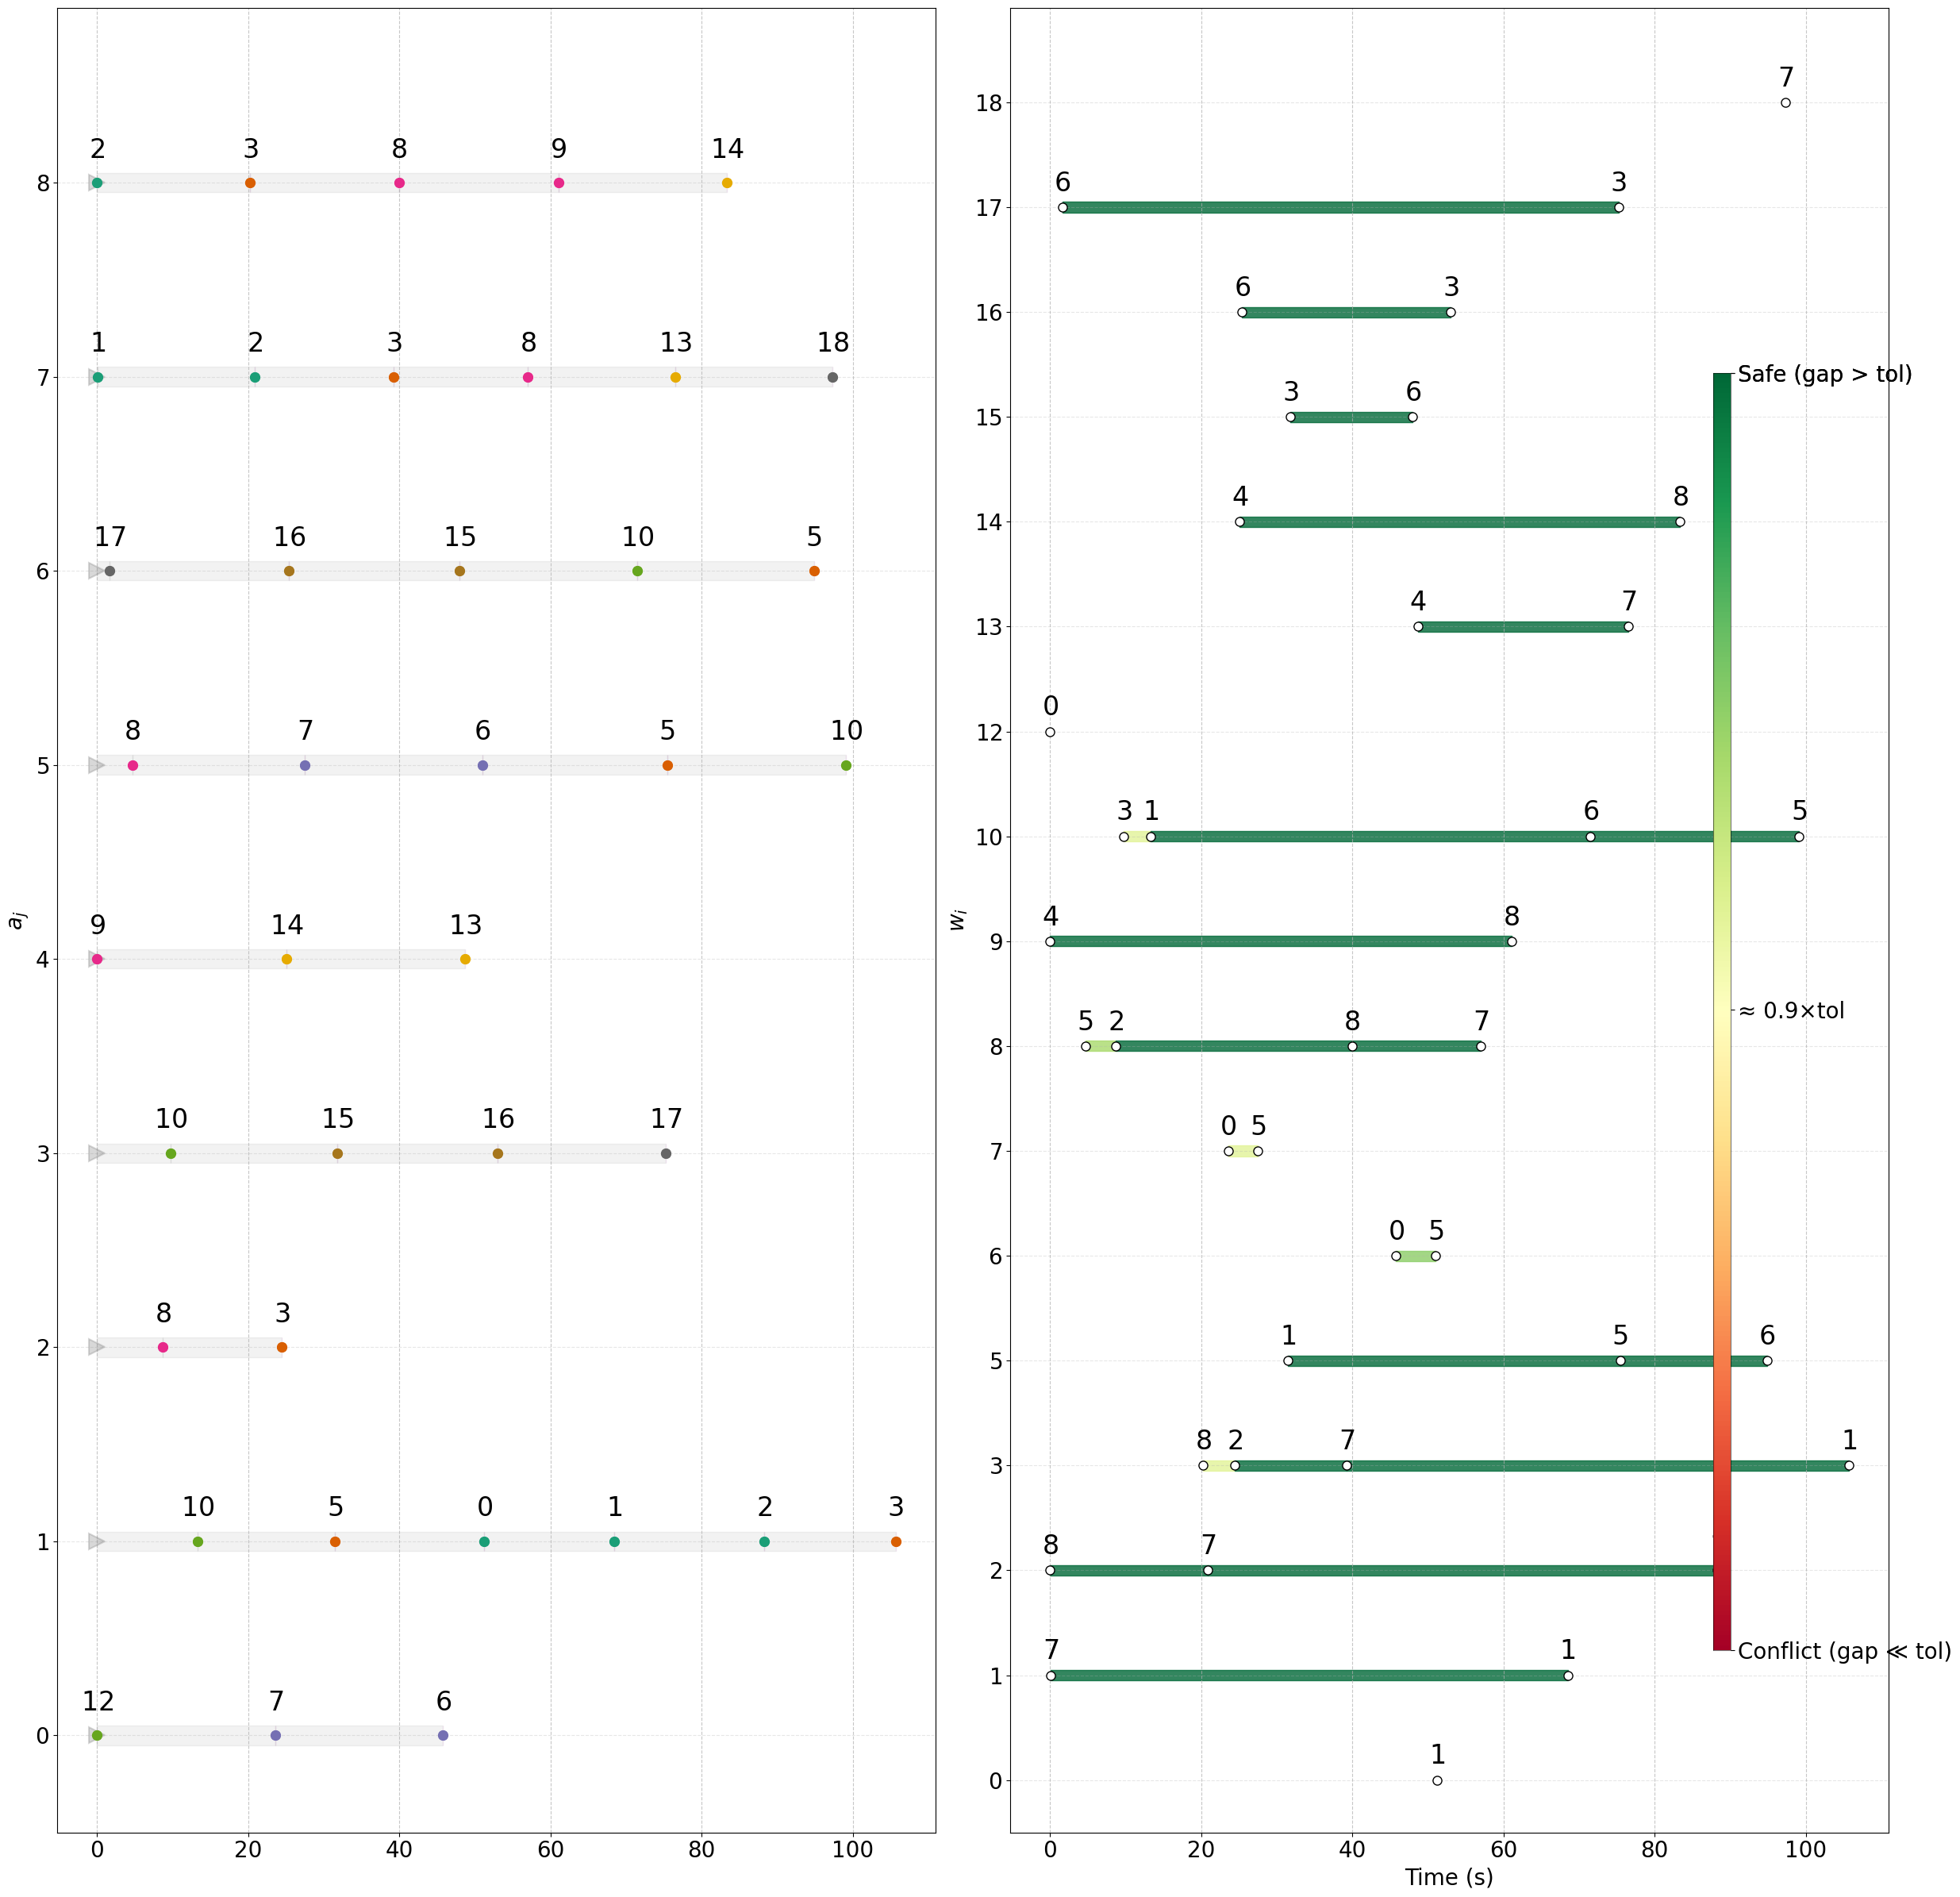

In [5]:
importlib.reload(visualize)

wp_locs = solution_data1["wp_xy"]
mask = solution_data1["mask"]
dist_mat = solution_data1["dist_mat"]
sd_mat = solution_data1["sd_mat"]
agent_routes = solution_data1["agent_routes"]
agent_schedules = solution_data1["agent_schedules"]
agent_colors = solution_data1["agent_colors"]
T_array = solution_data1["T_array"]
assoc_mat = solution_data1["association_mat"]
process_T = solution_data1["processing_time"]
tolArray = solution_data1["cat"]

visualize.plotNetwork(
    figuresize=(20,14), 
    wp_xy=wp_locs,
    mask = mask,
    dist_mat = dist_mat,
    sd_mat = sd_mat,
    routes = agent_routes, 
    schedules = agent_schedules,
    agent_colors = agent_colors, 
    showEdgeLength = False) 

visualize.plot_waypoint_agent_schedules(
    agent_routes,
    agent_schedules,
    T_array[-1],
    assoc_mat,
    process_T,
    tolArray,
    agent_colors,
    figuresize=(24,24),
    bar_thickness=0.05,
    marker_size=8
)



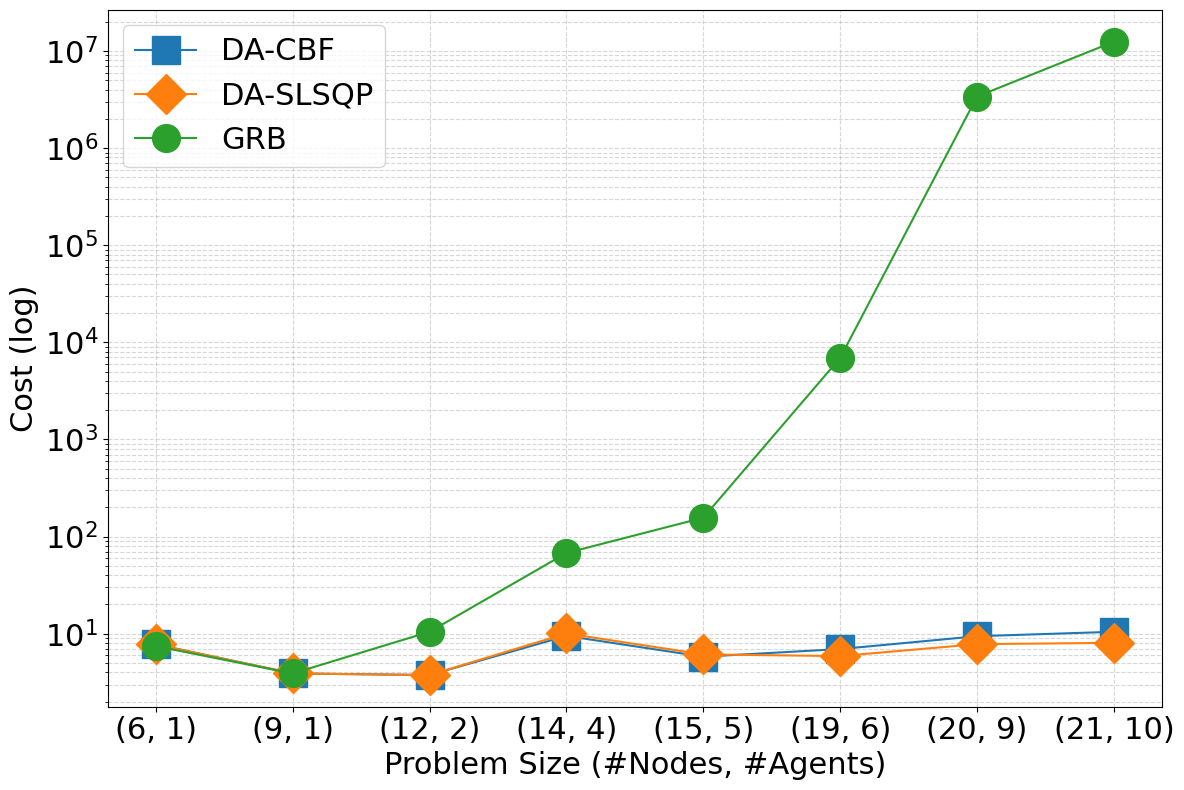

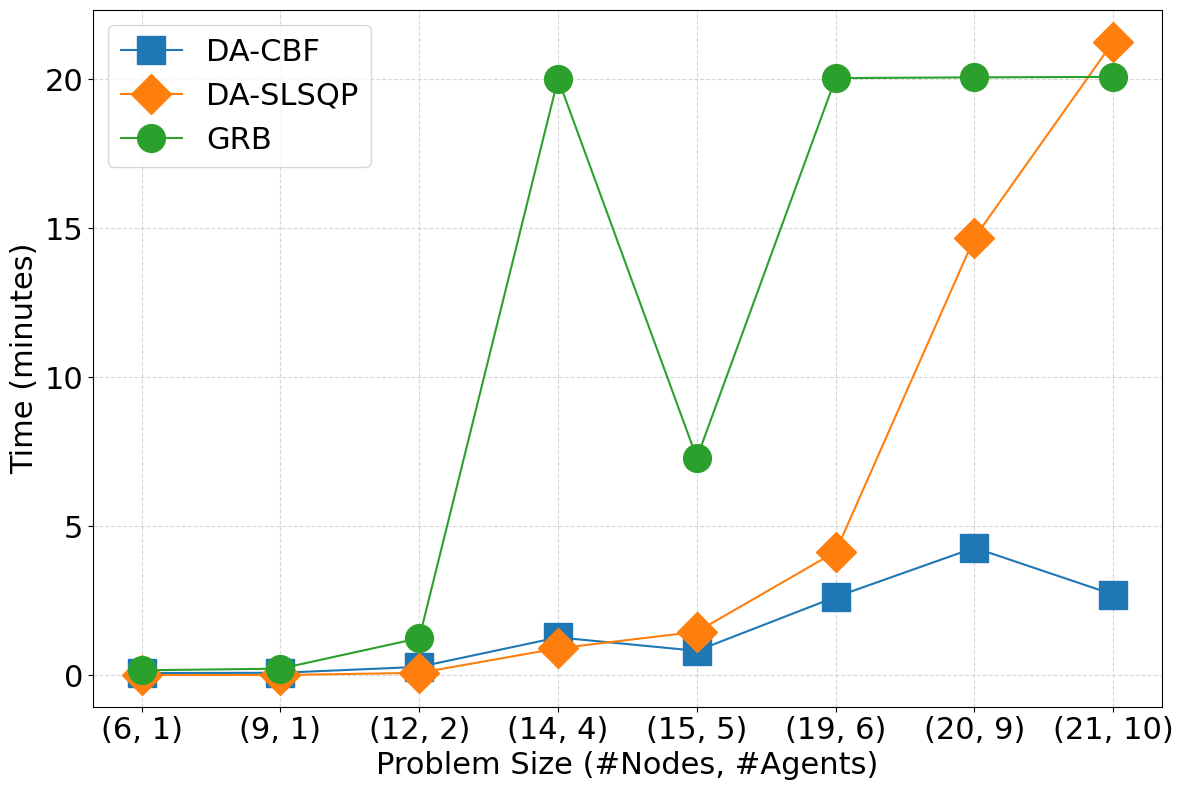

In [45]:
c_arr_mep = compare_data['c_arr_mep']
c_arr_slsqp = compare_data['c_arr_slsqp']
c_arr_gb = compare_data['c_arr_gb']
t_arr_mep = compare_data['t_arr_mep']
t_arr_slsqp = compare_data['t_arr_slsqp']
t_arr_gb = compare_data['t_arr_gb']
problem_size = [(6,1),(9,1),(12,2),(14,4),(15,5),(19,6),(20,9),(21,10)]

# Convert to arrays
c_arr_mep = np.array(c_arr_mep)
c_arr_slsqp = np.array(c_arr_slsqp)
c_arr_gb = np.array(c_arr_gb)

t_arr_mep = np.array(t_arr_mep)/60
t_arr_slsqp = np.array(t_arr_slsqp)/60
t_arr_gb = np.array(t_arr_gb)/60

# ----------------------------
# Normalize
# ----------------------------
c_min = np.minimum.reduce([c_arr_mep, c_arr_slsqp, c_arr_gb])
t_min = np.minimum.reduce([t_arr_mep, t_arr_slsqp, t_arr_gb])

rel_c_mep = c_arr_mep #/ c_min
rel_c_slsqp = c_arr_slsqp #/ c_min
rel_c_gb = c_arr_gb #/ c_min

rel_t_mep = t_arr_mep #/ t_min
rel_t_slsqp = t_arr_slsqp #/ t_min
rel_t_gb = t_arr_gb #/ t_min

# ----------------------------
# (1) Relative Cost Plot
# ----------------------------
plt.figure(figsize=(12,8))

plt.plot(rel_c_mep, label="DA-CBF", marker='s', markersize=20, markevery=1)
plt.plot(rel_c_slsqp, label="DA-SLSQP", marker='D', markersize=20, markevery=1)
plt.plot(rel_c_gb, label="GRB", marker='o', markersize=20, markevery=1)

# plt.axhline(1, linestyle='--', linewidth=2)

plt.xticks(range(len(problem_size)), [str(t) for t in problem_size], fontsize=22)
plt.yticks(fontsize=22)
plt.yscale("log")
plt.xlabel("Problem Size (#Nodes, #Agents)", fontsize=22)
plt.ylabel("Cost (log)", fontsize=22)
# plt.title("Cost Comparison")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()

# ----------------------------
# (2) Relative Time Plot
# ----------------------------
plt.figure(figsize=(12,8))

plt.plot(rel_t_mep, label="DA-CBF", marker='s', markersize=20, markevery=1)
plt.plot(rel_t_slsqp, label="DA-SLSQP", marker='D', markersize=20, markevery=1)
plt.plot(rel_t_gb, label="GRB", marker='o', markersize=20, markevery=1)

# plt.axhline(1, linestyle='--', linewidth=2)

plt.xticks(range(len(problem_size)), [str(t) for t in problem_size], fontsize=22)
plt.yticks(fontsize=22)
# plt.yscale("log")
plt.xlabel("Problem Size (#Nodes, #Agents)", fontsize=22)
plt.ylabel("Time (minutes)", fontsize=22)
# plt.title("Computation Time Comparison", fontsize=22)

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()